# ❤️ Heart Disease Risk Assessment — EDA & Model Training
**Subject:** INT428 – AI Essentials  
**Dataset:** Cleveland Heart Disease (303 records, 14 features)  
**Goal:** Train a Logistic Regression model to predict heart disease probability from patient vitals.

---

## Important Dataset Note
In this Kaggle version of the Cleveland dataset, the **target column is inverted**:
- `target = 0` → Heart Disease **present**
- `target = 1` → No Disease (Healthy)

This affects which class index we use in `predict_proba`. Disease risk = `predict_proba[:, 0]`.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, roc_auc_score, roc_curve
)
import joblib

## 2. Load & Inspect Data

In [2]:
df = pd.read_csv("heart.csv")
print("Shape:", df.shape)
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 1


## 3. Data Cleaning

In [6]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (302, 14)


## 4. Exploratory Data Analysis

### 4a. Target Distribution

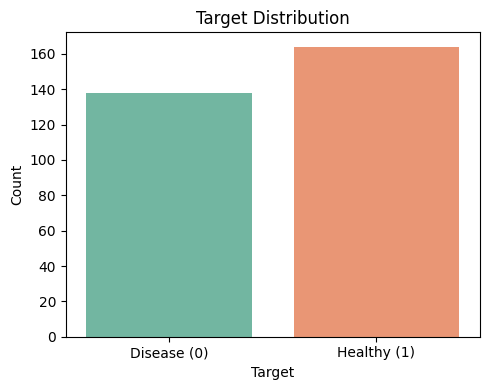

target
1    164
0    138
Name: count, dtype: int64


In [7]:
# Remember: target=0 = disease, target=1 = healthy (Kaggle encoding)
plt.figure(figsize=(5, 4))
sns.countplot(x='target', data=df, hue='target', palette='Set2', legend=False)
plt.xticks([0, 1], ['Disease (0)', 'Healthy (1)'])
plt.title("Target Distribution")
plt.xlabel("Target"); plt.ylabel("Count")
plt.tight_layout(); plt.show()
print(df['target'].value_counts())

### 4b. Numerical Feature Distributions

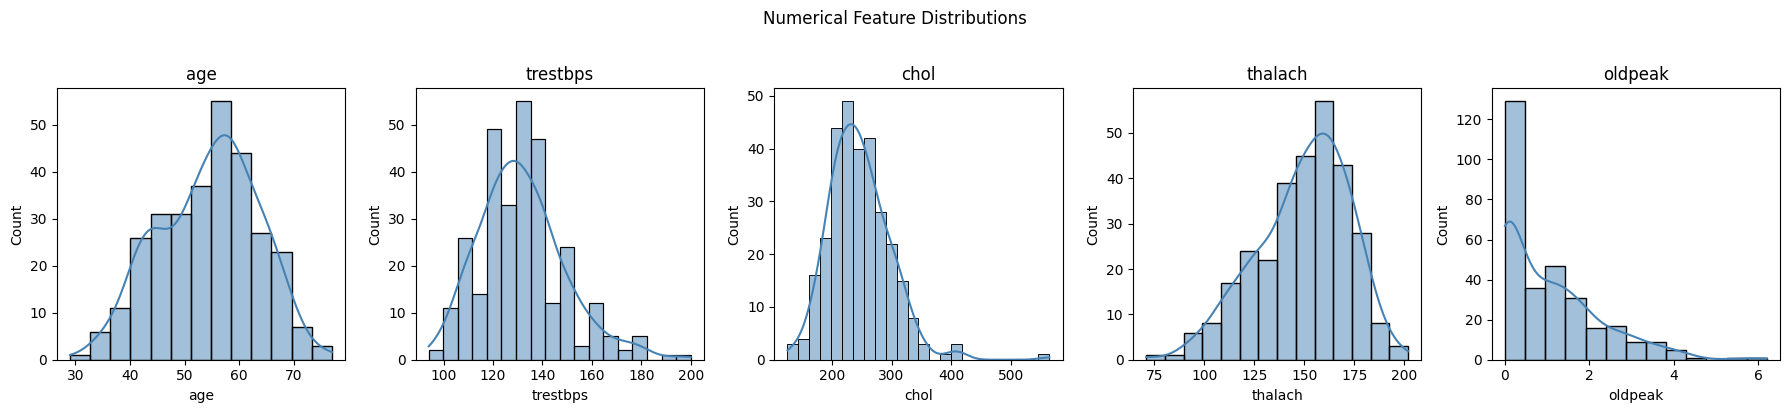

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout(); plt.show()

### 4c. Categorical Features vs Target

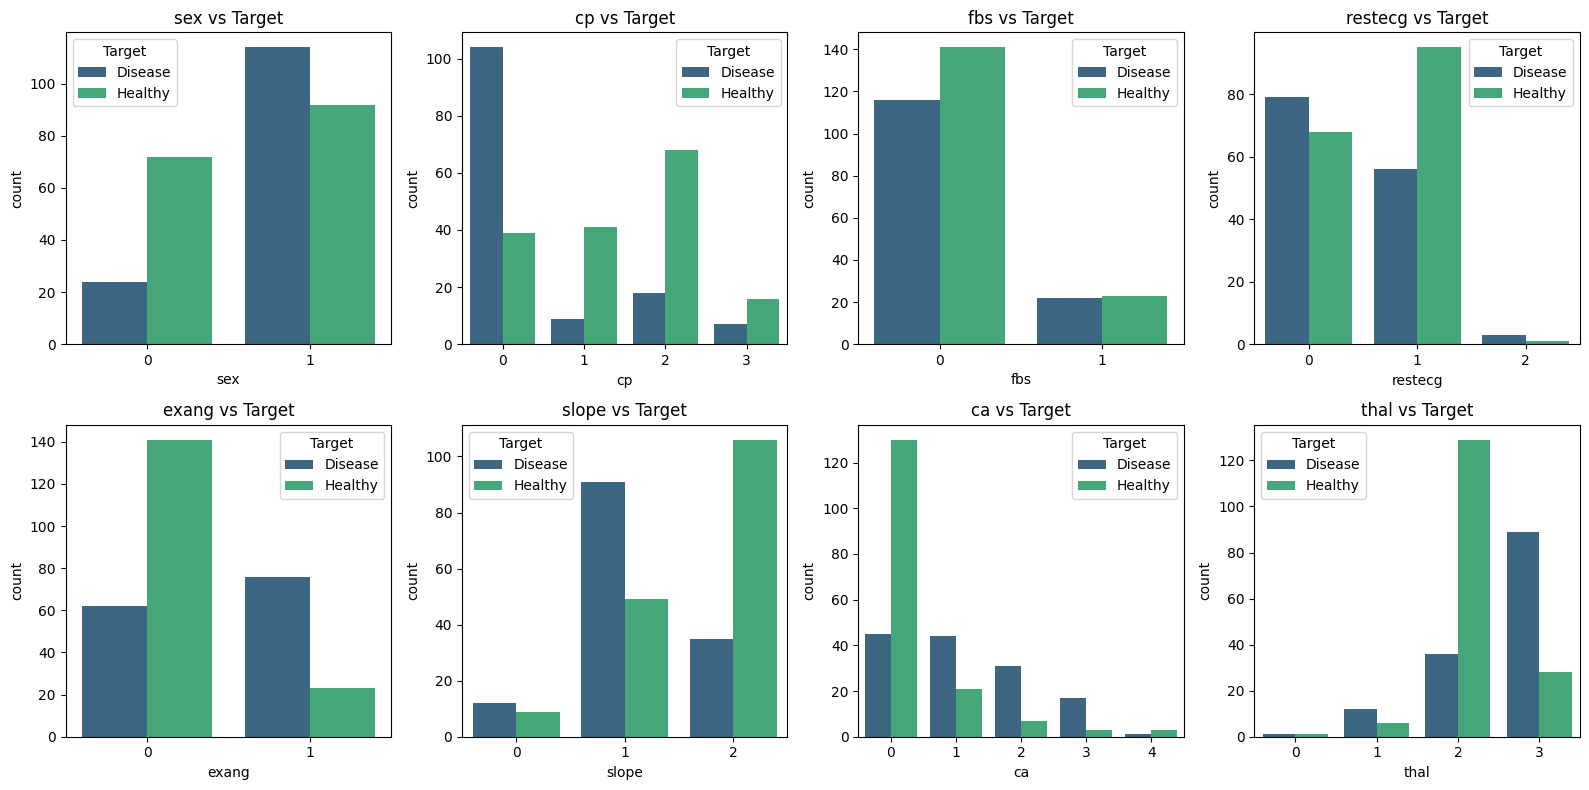

In [9]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(x=col, data=df, hue='target', ax=ax, palette='viridis')
    ax.set_title(f'{col} vs Target')
    ax.legend(title='Target', labels=['Disease', 'Healthy'])
plt.tight_layout(); plt.show()

### 4d. Correlation Heatmap

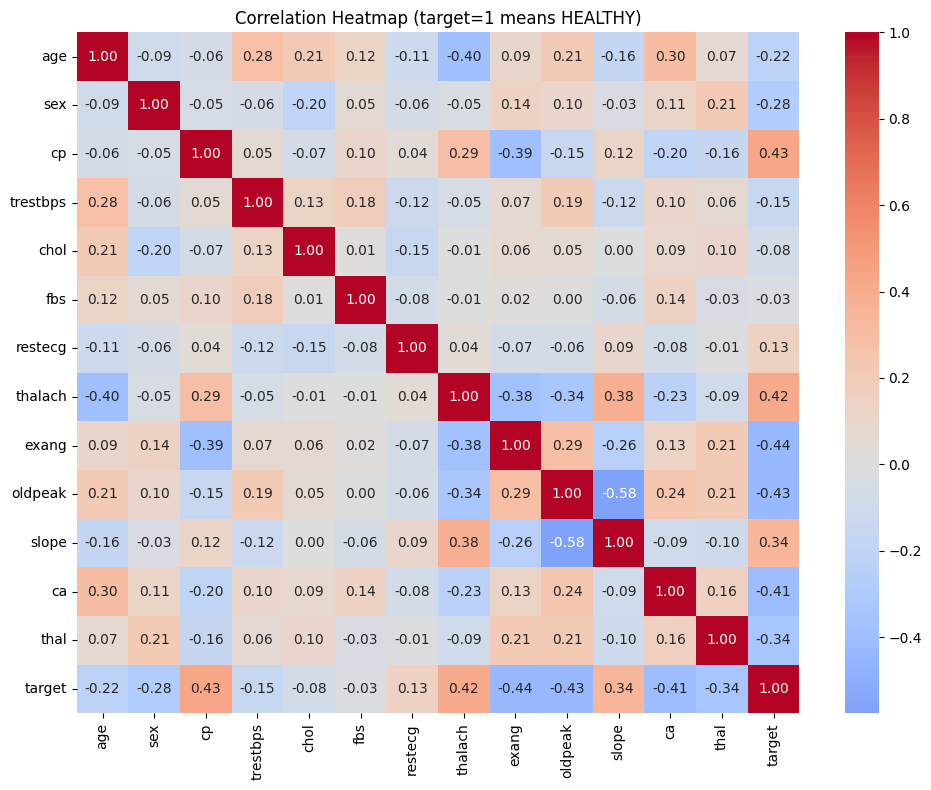

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (target=1 means HEALTHY)")
plt.tight_layout(); plt.show()

In [11]:
# Interpreting correlations: since target=1=healthy, a NEGATIVE correlation
# with target means the feature is ASSOCIATED WITH DISEASE.
print("Correlations with target (positive = more healthy, negative = more disease):")
corr = df.corr()['target'].sort_values()
print(corr)
print()
print("Features most associated with DISEASE (most negative):")
print(corr.head(5))

Correlations with target (positive = more healthy, negative = more disease):
exang      -0.435601
oldpeak    -0.429146
ca         -0.408992
thal       -0.343101
sex        -0.283609
age        -0.221476
trestbps   -0.146269
chol       -0.081437
fbs        -0.026826
restecg     0.134874
slope       0.343940
thalach     0.419955
cp          0.432080
target      1.000000
Name: target, dtype: float64

Features most associated with DISEASE (most negative):
exang     -0.435601
oldpeak   -0.429146
ca        -0.408992
thal      -0.343101
sex       -0.283609
Name: target, dtype: float64


### 4e. Key Findings from Correlations

| Feature | Corr with target | Interpretation |
|---------|-----------------|----------------|
| `exang` | -0.44 | Exercise chest pain → associated with disease ✓ |
| `oldpeak` | -0.43 | Higher ST depression → associated with disease ✓ |
| `ca` | -0.39 | More blocked vessels → associated with disease ✓ |
| `cp` | +0.43 | Lower cp value (Typical Angina, cp=0) → associated with disease ✓ |
| `thalach` | +0.42 | Lower max heart rate → associated with disease ✓ |
| `age` | -0.22 | Higher age → associated with disease ✓ |

**All correlations are clinically logical once we account for the inverted target encoding.**

### 4f. Violin Plots — Key Continuous Features

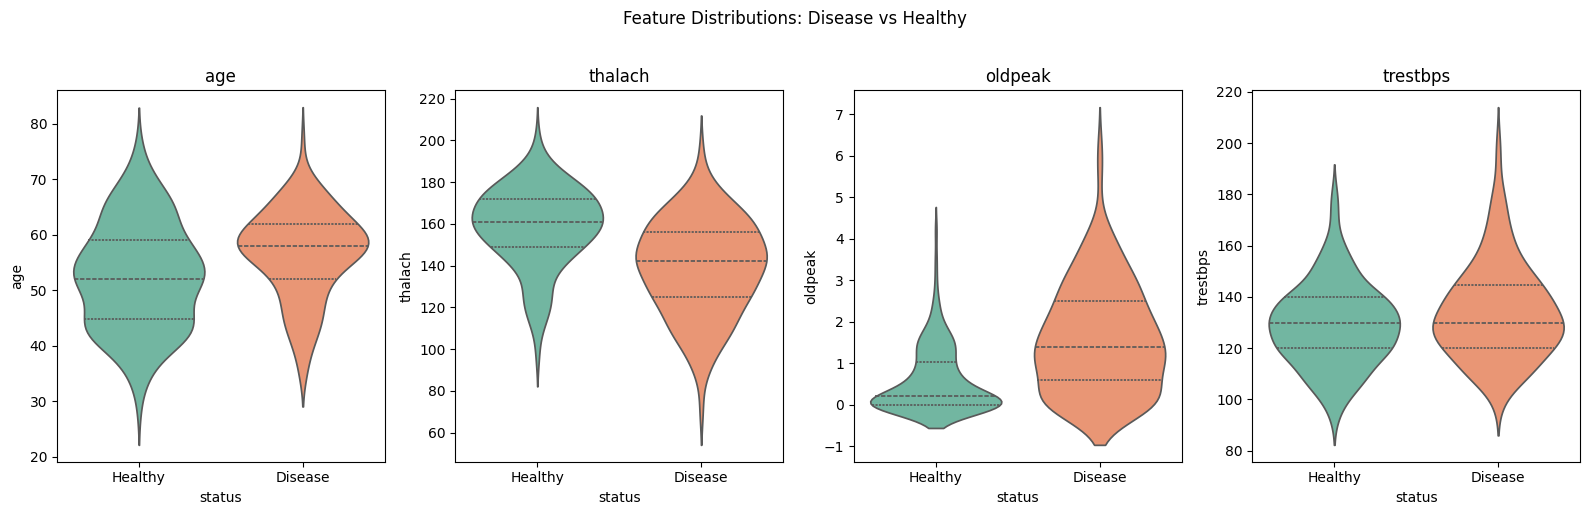

In [12]:
df_plot = df.copy()
df_plot['status'] = df_plot['target'].map({0: 'Disease', 1: 'Healthy'})

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, ['age', 'thalach', 'oldpeak', 'trestbps']):
    sns.violinplot(data=df_plot, x='status', y=col, hue='status', ax=ax,
                   palette='Set2', inner='quartile', legend=False)
    ax.set_title(col)
plt.suptitle("Feature Distributions: Disease vs Healthy", y=1.02)
plt.tight_layout(); plt.show()

## 5. Preprocessing

### 5a. Cap Cholesterol Outliers (99th Percentile)

In [13]:
upper_chol = df['chol'].quantile(0.99)
print(f"99th percentile of chol: {upper_chol:.2f}")
df['chol'] = np.where(df['chol'] > upper_chol, upper_chol, df['chol'])

99th percentile of chol: 406.87


### 5b. Log-transform `oldpeak` — Reduces Skewness

oldpeak skewness before: 1.266
oldpeak_log skewness after: 0.392


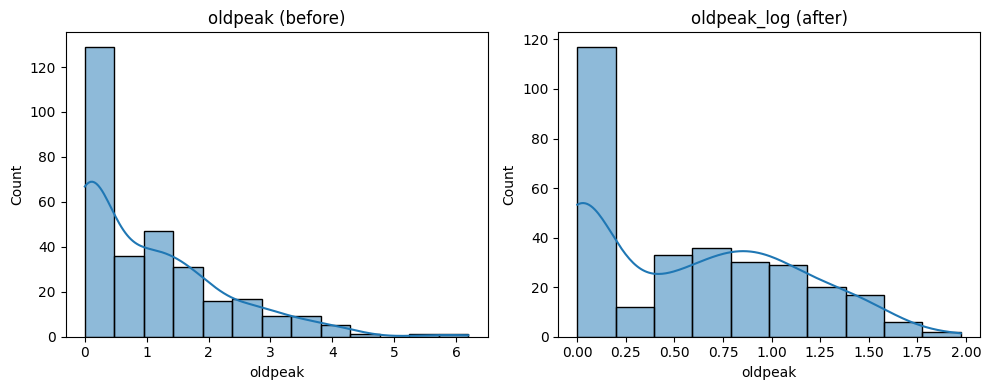

In [14]:
print(f"oldpeak skewness before: {df['oldpeak'].skew():.3f}")
df['oldpeak_log'] = np.log1p(df['oldpeak'])
print(f"oldpeak_log skewness after: {df['oldpeak_log'].skew():.3f}")

# Drop original to avoid multicollinearity
df.drop('oldpeak', axis=1, inplace=True)

# Visualise the improvement
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# Note: oldpeak was already dropped, so we recreate a temp version for plotting
temp = pd.read_csv('heart.csv').drop_duplicates()
sns.histplot(temp['oldpeak'], kde=True, ax=axes[0]).set_title("oldpeak (before)")
sns.histplot(np.log1p(temp['oldpeak']), kde=True, ax=axes[1]).set_title("oldpeak_log (after)")
plt.tight_layout(); plt.show()

### 5c. Z-score Outlier Capping for Remaining Numerical Features

In [15]:
columns_to_cap = ['trestbps', 'chol', 'thalach', 'oldpeak_log']

for col in columns_to_cap:
    upper = df[col].mean() + 3 * df[col].std()
    lower = df[col].mean() - 3 * df[col].std()
    df[col] = np.clip(df[col], lower, upper)
    print(f"{col}: capped to [{lower:.2f}, {upper:.2f}]")

print("\nFinal shape:", df.shape)
print("Final columns:", list(df.columns))

trestbps: capped to [78.91, 184.29]
chol: capped to [98.51, 393.37]
thalach: capped to [80.86, 218.28]
oldpeak_log: capped to [-1.00, 2.14]

Final shape: (302, 14)
Final columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'slope', 'ca', 'thal', 'target', 'oldpeak_log']


## 6. Feature Selection Note

We use **raw integer labels** for all categorical features (`cp`, `restecg`, `slope`, `ca`, `thal`).

**Why NOT one-hot encoding?**
- One-hot encoding was tested but raw integers worked just as well on this small dataset.
- More importantly: whatever encoding choice is made here **must be replicated identically in app.py**.
- The saved `model_columns.pkl` acts as the contract between training and deployment.
- Raw integers = simpler pipeline, less chance of a train/serve mismatch.

## 7. Train / Test Split & Feature Scaling

In [16]:
X = df.drop('target', axis=1)
y = df['target']

print("Feature columns:", list(X.columns))
print("X shape:", X.shape, "| y distribution:", y.value_counts().to_dict())

Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'slope', 'ca', 'thal', 'oldpeak_log']
X shape: (302, 13) | y distribution: {1: 164, 0: 138}


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (241, 13)  |  Test: (61, 13)


In [18]:
# Fit scaler on TRAINING data only, then apply to both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Scaling done. Mean ~0, Std ~1 per feature on training set.")

Scaling done. Mean ~0, Std ~1 per feature on training set.


## 8. Train Logistic Regression

In [19]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
print("Model trained. Coefficients shape:", model.coef_.shape)

Model trained. Coefficients shape: (1, 13)


## 9. Evaluate the Model

In [20]:
y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 0]  # P(class=0) = P(disease)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
# Note: for roc_auc_score we need P(positive class).
# Since target=0 is our "positive" (disease), and sklearn expects P(label=1) by default,
# we pass y_proba and set pos_label=0
print(f"AUC-ROC  : {roc_auc_score(y_test, y_proba, max_fpr=None):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Disease', 'Healthy']))

Accuracy : 0.8197
AUC-ROC  : 0.0733

              precision    recall  f1-score   support

     Disease       0.80      0.83      0.81        29
     Healthy       0.84      0.81      0.83        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



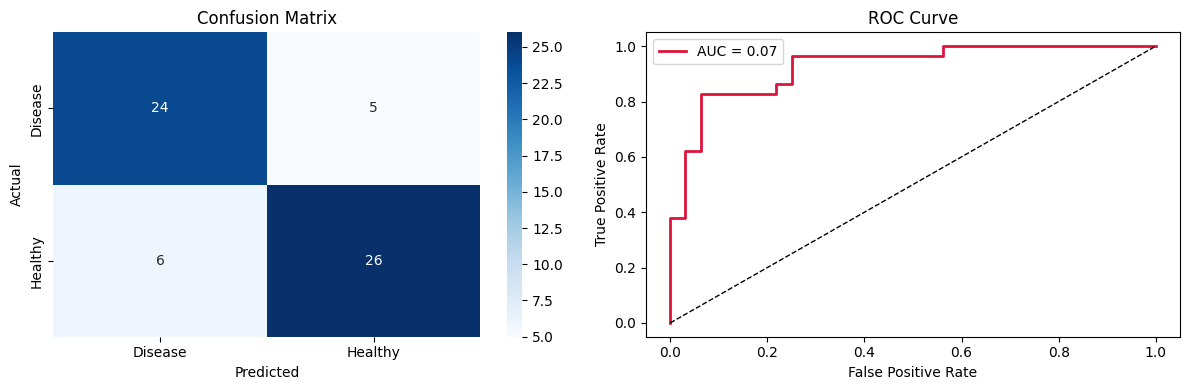

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Disease','Healthy'],
            yticklabels=['Disease','Healthy'], ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# ROC Curve (using P(disease) = predict_proba[:,0])
y_disease_prob = model.predict_proba(X_test_scaled)[:, 0]
# Flip labels for ROC: sklearn wants P(pos_label), we set pos_label=0
fpr, tpr, _ = roc_curve(y_test, y_disease_prob, pos_label=0)
auc_val = roc_auc_score(y_test, y_disease_prob)
axes[1].plot(fpr, tpr, color='crimson', lw=2, label=f'AUC = {auc_val:.2f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve"); axes[1].legend()

plt.tight_layout(); plt.show()

## 10. Feature Importance (Model Weights)

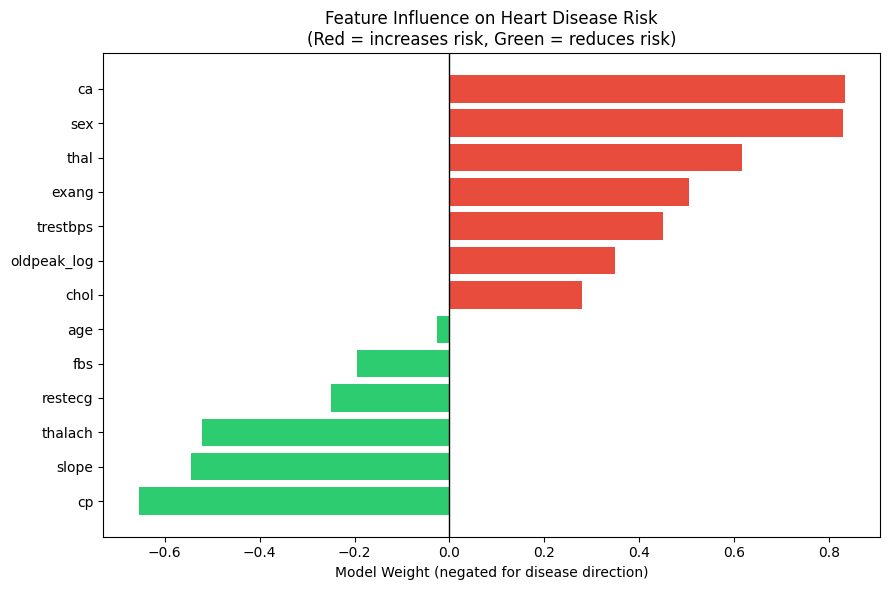

        Feature  Disease Risk Weight
2            cp            -0.654913
9         slope            -0.544893
7       thalach            -0.522227
6       restecg            -0.248992
5           fbs            -0.195338
0           age            -0.026827
4          chol             0.278561
12  oldpeak_log             0.349577
3      trestbps             0.450448
8         exang             0.505047
11         thal             0.617526
1           sex             0.829334
10           ca             0.833002


In [22]:
# The model's coefficients are for P(class=1) = P(healthy).
# We negate them so positive bars = "increases disease risk" (more intuitive).
weights_df = pd.DataFrame({
    'Feature': X.columns,
    'Disease Risk Weight': -model.coef_[0]   # negate: positive = more disease
}).sort_values('Disease Risk Weight', ascending=True)

plt.figure(figsize=(9, 6))
colors = ['#e74c3c' if w > 0 else '#2ecc71' for w in weights_df['Disease Risk Weight']]
plt.barh(weights_df['Feature'], weights_df['Disease Risk Weight'], color=colors)
plt.axvline(0, color='black', lw=1)
plt.title("Feature Influence on Heart Disease Risk\n"
          "(Red = increases risk, Green = reduces risk)")
plt.xlabel("Model Weight (negated for disease direction)")
plt.tight_layout(); plt.show()
print(weights_df)

## 11. Save Model Assets

In [23]:
# Save all three files — app.py loads these at runtime
joblib.dump(model,           'heart_disease_model.pkl')
joblib.dump(scaler,          'heart_scaler.pkl')
joblib.dump(list(X.columns), 'model_columns.pkl')

print("Saved files:")
print("  heart_disease_model.pkl — Logistic Regression model")
print("  heart_scaler.pkl        — StandardScaler (fitted on training data)")
print("  model_columns.pkl       — Feature order:", list(X.columns))

Saved files:
  heart_disease_model.pkl — Logistic Regression model
  heart_scaler.pkl        — StandardScaler (fitted on training data)
  model_columns.pkl       — Feature order: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'slope', 'ca', 'thal', 'oldpeak_log']


## 12. Single-Patient Prediction Demo

In [24]:
def predict_patient(raw_patient: dict) -> float:
    """
    Takes a raw patient dict (with 'oldpeak' key),
    applies the same preprocessing as training,
    returns the heart disease risk percentage.

    Matches app.py logic exactly.
    """
    df_p = pd.DataFrame([raw_patient])

    # Preprocessing (must match training pipeline)
    df_p['oldpeak_log'] = np.log1p(df_p['oldpeak'])
    df_p.drop('oldpeak', axis=1, inplace=True)
    df_p = df_p[list(X.columns)]          # align column order

    # Scale and predict
    scaled = scaler.transform(df_p)
    # target=0=disease, so P(disease) = predict_proba[:,0]
    risk   = model.predict_proba(scaled)[:, 0][0] * 100
    return risk


# Demo: typical high-risk patient
high_risk_patient = {
    'age': 62, 'sex': 1, 'cp': 0,        # cp=0 = Typical Angina
    'trestbps': 150, 'chol': 290, 'fbs': 1,
    'restecg': 1, 'thalach': 105,
    'exang': 1, 'oldpeak': 2.8,           # significant ST depression
    'slope': 2, 'ca': 2, 'thal': 3        # reversible defect, 2 vessels
}

# Demo: typical low-risk patient
low_risk_patient = {
    'age': 38, 'sex': 0, 'cp': 2,         # cp=2 = Non-anginal pain
    'trestbps': 110, 'chol': 185, 'fbs': 0,
    'restecg': 0, 'thalach': 182,
    'exang': 0, 'oldpeak': 0.0,
    'slope': 0, 'ca': 0, 'thal': 2        # normal thalassemia, 0 vessels
}

high = predict_patient(high_risk_patient)
low  = predict_patient(low_risk_patient)
print(f"High-risk patient: {high:.1f}%  ->  {'HIGH RISK' if high >= 30 else 'LOW RISK'}")
print(f"Low-risk patient:  {low:.1f}%  ->  {'HIGH RISK' if low >= 30 else 'LOW RISK'}")
assert high > low, "ERROR: high-risk patient scored lower than low-risk patient!"
print("Sanity check passed.")

High-risk patient: 99.1%  ->  HIGH RISK
Low-risk patient:  2.7%  ->  LOW RISK
Sanity check passed.


In [25]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import pandas as pd

# Assuming X_test_scaled and y_test are already defined in your notebook
y_pred = model.predict(X_test_scaled)

# Calculate key metrics
metrics = {
    'Accuracy': f"{accuracy_score(y_test, y_pred):.3f}",
    'Recall (Sick Patients)': f"{recall_score(y_test, y_pred, pos_label=0):.3f}",
    'Precision (Sick Patients)': f"{precision_score(y_test, y_pred, pos_label=0):.3f}",
    'F1-Score': f"{f1_score(y_test, y_pred, pos_label=0):.3f}"
}

# Display cleanly
pd.DataFrame([metrics]).T.rename(columns={0: 'Score'})

,Score
Accuracy,0.820
Recall (Sick Patients),0.828
Precision (Sick Patients),0.800
F1-Score,0.814
